In [1]:
from _setup import setup_project_root
PROJECT_ROOT = setup_project_root()
PROJECT_ROOT

WindowsPath('D:/AirPollutionPrediction-CNN-BiLSTM')

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib
import tensorflow as tf
load_model = tf.keras.models.load_model

from models.cnn_bilstm import train_cnn_bilstm, predict_cnn_bilstm

In [3]:
PROJECT_ROOT = Path.cwd().parent   
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"

STATION_SPLIT_DIR = DATA_DIR / "station_split_24havg"   
pm25_scaler = joblib.load(ARTIFACTS_DIR / "pm25_scaler.pkl")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("STATION_SPLIT_DIR exists:", STATION_SPLIT_DIR.exists())
print("Loaded pm25_scaler:", ARTIFACTS_DIR / "pm25_scaler.pkl")


PROJECT_ROOT: d:\AirPollutionPrediction-CNN-BiLSTM
STATION_SPLIT_DIR exists: True
Loaded pm25_scaler: d:\AirPollutionPrediction-CNN-BiLSTM\artifacts\pm25_scaler.pkl


c:\Users\KimNgan\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
target_col = "PM2.5_24h_avg"
id_cols = ["Station_No", "date"]

SEQ_LEN = 48
EPOCHS = 200
BATCH = 64
PATIENCE = 20
LR = 3e-4
LSTM_UNITS = 128

print("Target:", target_col)
print("SEQ_LEN:", SEQ_LEN)


Target: PM2.5_24h_avg
SEQ_LEN: 48


In [5]:
import numpy as np
from sklearn.metrics import r2_score

def metrics_real_from_scaled(y_true_scaled, y_pred_scaled, scaler, eps=1e-6, mape_threshold=1.0):
    # Đảm bảo đầu vào là mảng phẳng
    y_true_scaled = np.asarray(y_true_scaled).reshape(-1)
    y_pred_scaled = np.asarray(y_pred_scaled).reshape(-1)

    # Giải mã (Inverse Transform) về đơn vị thực tế (µg/m³)
    yt = scaler.inverse_transform(y_true_scaled.reshape(-1,1)).ravel()
    yp = scaler.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()

    # Tính toán các chỉ số cơ bản
    diff = yp - yt
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))

    # --- TÍNH R^2 SCORE ---
    # R2 = 1 là dự báo hoàn hảo. R2 = 0 là dự báo bằng giá trị trung bình.
    r2 = float(r2_score(yt, yp))

    # Tính MAPE với ngưỡng loại bỏ giá trị nhỏ (tránh chia cho ~0)
    mask = np.abs(yt) >= mape_threshold
    mape = float(np.mean(np.abs(diff[mask]) / np.abs(yt[mask]))) if np.any(mask) else float("nan")

    # Tính Hệ số tương quan Pearson (Correlation)
    if np.std(yt) < eps or np.std(yp) < eps:
        corr = float("nan")
    else:
        corr = float(np.corrcoef(yt, yp)[0,1])

    return {
        "Correlation": corr, 
        "R2": r2,           # Chỉ số mới
        "RMSE": rmse, 
        "MAPE": mape, 
        "MAE": mae
    }

In [6]:
station_dirs = sorted([p for p in STATION_SPLIT_DIR.glob("station_*") if p.is_dir()],
                      key=lambda p: int(p.name.split("_")[1]))

print("Found stations:", [p.name for p in station_dirs])


Found stations: ['station_1', 'station_2', 'station_3', 'station_4', 'station_5', 'station_6']


In [7]:
st_dir = STATION_SPLIT_DIR / "station_1"

train_df = pd.read_csv(st_dir / "train.csv")
val_df   = pd.read_csv(st_dir / "val.csv")
test_df  = pd.read_csv(st_dir / "test.csv")

feature_cols = [c for c in train_df.columns if c not in (id_cols + [target_col])]

X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df[target_col].values.astype(np.float32)

X_val = val_df[feature_cols].values.astype(np.float32)
y_val = val_df[target_col].values.astype(np.float32)

X_test = test_df[feature_cols].values.astype(np.float32)
y_test = test_df[target_col].values.astype(np.float32)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Num features:", len(feature_cols))


Shapes: (8096, 33) (1734, 33) (1736, 33)
Num features: 33


✅ Đã xử lý xong Station 1
✅ Đã xử lý xong Station 2
✅ Đã xử lý xong Station 3
✅ Đã xử lý xong Station 4
✅ Đã xử lý xong Station 5
✅ Đã xử lý xong Station 6


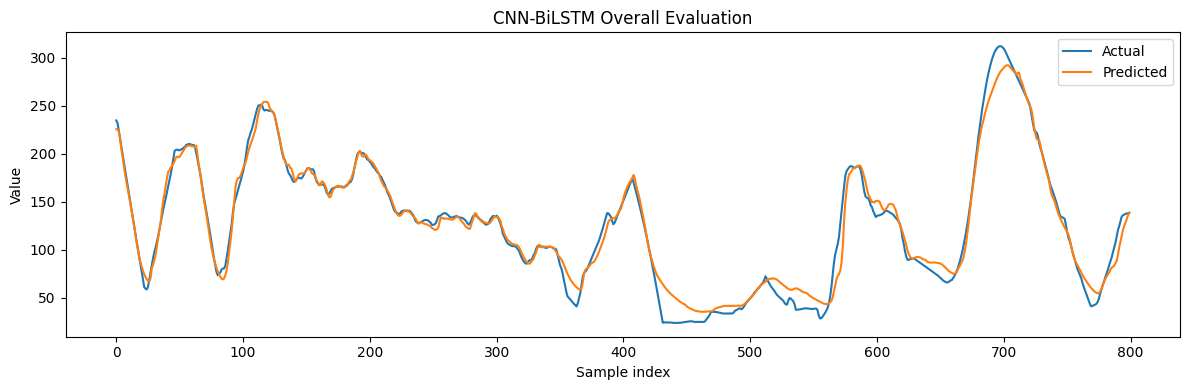

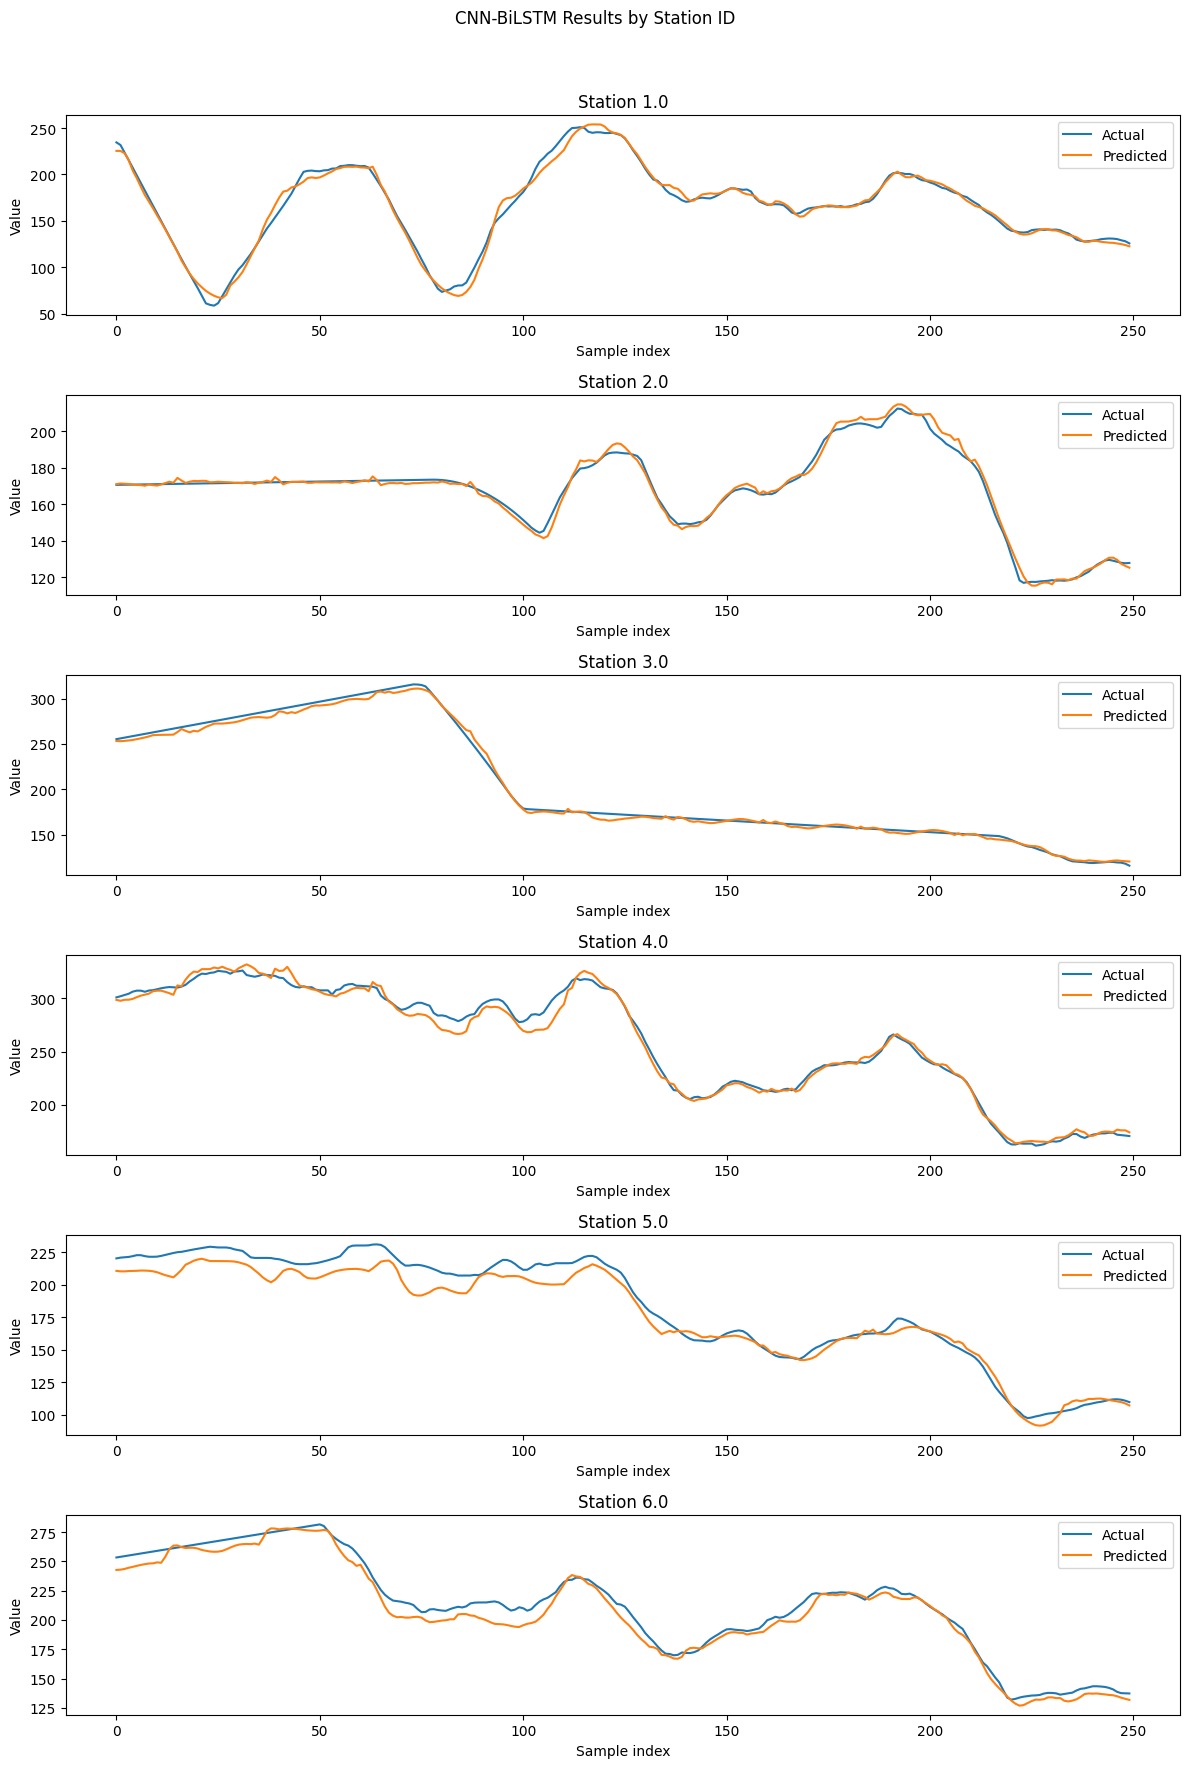

   Station_No  n_test  Correlation        R2       RMSE      MAPE       MAE
0           1    1688     0.985773  0.968292  10.531547  0.102112  7.101685
1           2    1688     0.995178  0.989605   3.207941  0.019301  2.395723
2           3    1688     0.996437  0.992272   4.629591  0.031493  3.398873
3           4    1688     0.995880  0.991680   5.245996  0.022811  3.982021
4           5    1688     0.982340  0.948523  12.117559  0.120535  7.660173
5           6    1685     0.995141  0.984772   5.275030  0.031820  4.194633


In [8]:
from evaluation.plots import plot_actual_vs_pred, plot_actual_vs_pred_by_station
all_rows = []
all_y_true = []
all_y_pred = []
all_st_ids = [] # Lưu ID dưới dạng số để vượt qua kiểm tra float64

for st_dir in station_dirs:
    # Lấy số ID trạm từ tên thư mục (ví dụ: "station_1" -> 1)
    st_id = int(st_dir.name.split("_")[1]) 

    # --- Load dữ liệu ---
    test_df = pd.read_csv(st_dir / "test.csv")
    X_test = test_df[feature_cols].values.astype(np.float32)
    y_test = test_df[target_col].values.astype(np.float32)

    # --- Load model và Dự báo ---
    ckpt = ARTIFACTS_DIR / f"cnn_bilstm_station{st_id}_24havg_seq{SEQ_LEN}_u{LSTM_UNITS}.keras"
    best = load_model(ckpt)
    
    # Dự báo (hàm này trả về kết quả đã qua xử lý sequence)
    y_pred_scaled = predict_cnn_bilstm(best, X_test, seq_len=SEQ_LEN)
    y_true_scaled = y_test[SEQ_LEN:] 

    # --- Chuyển về giá trị thực (Inverse Scale) ---
    # Cần reshape(-1, 1) cho scaler và flatten() lại cho mảng 1D
    y_p_real = pm25_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_t_real = pm25_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()
    
    # Lưu trữ kết quả (Sử dụng ID số để tránh lỗi string-to-float)
    all_y_pred.append(y_p_real)
    all_y_true.append(y_t_real)
    all_st_ids.append(np.full(len(y_t_real), st_id)) 

    # --- Tính Metric và lưu vào bảng ---
    m = metrics_real_from_scaled(y_true_scaled, y_pred_scaled, pm25_scaler, eps=1.0)
    row = {"Station_No": st_id, "n_test": int(len(y_true_scaled))}
    row.update(m)
    all_rows.append(row)
    
    print(f"✅ Đã xử lý xong Station {st_id}")

# --- Gộp toàn bộ dữ liệu ---
final_y_true = np.concatenate(all_y_true)
final_y_pred = np.concatenate(all_y_pred)
final_st_ids = np.concatenate(all_st_ids)

# ---------------------------------------------------------
# GỌI CÁC HÀM VẼ (SỬ DỤNG DỮ LIỆU ĐÃ GỘP)
# ---------------------------------------------------------

# 1. Vẽ tổng hợp toàn bộ (không phân biệt trạm)
plot_actual_vs_pred(
    y_true=final_y_true, 
    y_pred=final_y_pred,
    title="CNN-BiLSTM Overall Evaluation",
    n_points=800 # Vẽ 800 điểm cho đỡ lag
)

# 2. Vẽ chi tiết 6 trạm (Sử dụng ID số)
plot_actual_vs_pred_by_station(
    station_ids=final_st_ids, # Mảng số [1.0, 1.0, ..., 2.0, 2.0]
    y_true=final_y_true,
    y_pred=final_y_pred,
    title="CNN-BiLSTM Results by Station ID",
    n_points_per_station=250,
    max_stations=len(station_dirs),
    figsize=(12, 3 * len(station_dirs)) # Tự động giãn chiều cao
)

# Hiển thị bảng tổng kết
results_df = pd.DataFrame(all_rows).sort_values("Station_No").reset_index(drop=True)
print(results_df)

In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- BƯỚC 1: ĐỊNH NGHĨA HÀM ĐÁNH GIÁ TỔNG QUÁT ---
def evaluate_global_model_performance(model_type, artifacts_dir, station_dirs, feature_cols, target_col, scaler, seq_len=48):
    all_y_true = []
    all_y_pred = []
    
    print(f"🧐 Đang xử lý mô hình: {model_type.upper()}...")
    
    for st_dir in station_dirs:
        st_id = int(st_dir.name.split("_")[1])
        
        # Xác định đường dẫn file model tương ứng
        if model_type == 'cnn_bilstm':
            model_path = artifacts_dir / f"cnn_bilstm_station{st_id}_24havg_seq{seq_len}_u{LSTM_UNITS}.keras"
        elif model_type == 'rnn':
            model_path = artifacts_dir / f"simple_rnn_station{st_id}_seq{seq_len}.keras"
        else: # mlp
            model_path = artifacts_dir / f"mlp_station{st_id}_seq{seq_len}.keras"
            
        if not model_path.exists():
            print(f"⚠️ Không tìm thấy: {model_path.name}")
            continue
            
        # Load model và dữ liệu test
        model = tf.keras.models.load_model(model_path)
        test_df = pd.read_csv(st_dir / "test.csv")
        X_test_raw = test_df[feature_cols].values.astype(np.float32)
        y_test_raw = test_df[target_col].values.astype(np.float32)
        
        # Dự báo tùy theo kiến trúc
        if model_type == 'cnn_bilstm':
            y_pred_scaled = predict_cnn_bilstm(model, X_test_raw, seq_len=seq_len)
        else:
            X_test_seq, _ = create_sequences(X_test_raw, seq_len)
            y_pred_scaled = model.predict(X_test_seq, verbose=0)
            
        y_true_scaled = y_test_raw[seq_len:]
        
        all_y_true.append(y_true_scaled)
        all_y_pred.append(y_pred_scaled)
    
    # Gộp kết quả tất cả các trạm và tính Metric
    final_true = np.concatenate(all_y_true)
    final_pred = np.concatenate(all_y_pred)
    return metrics_real_from_scaled(final_true, final_pred, scaler)

# --- BƯỚC 2: CHẠY ĐÁNH GIÁ CHO 3 MODELS ---
results_summary = []

# Đánh giá và thêm vào list
m_cnn = evaluate_global_model_performance('cnn_bilstm', ARTIFACTS_DIR, station_dirs, feature_cols, target_col, pm25_scaler)
results_summary.append({"Model": "CNN-BiLSTM", **m_cnn})

m_rnn = evaluate_global_model_performance('rnn', ARTIFACTS_DIR, station_dirs, feature_cols, target_col, pm25_scaler)
results_summary.append({"Model": "Simple RNN", **m_rnn})

m_mlp = evaluate_global_model_performance('mlp', ARTIFACTS_DIR, station_dirs, feature_cols, target_col, pm25_scaler)
results_summary.append({"Model": "MLP", **m_mlp})

🧐 Đang xử lý mô hình: CNN_BILSTM...
🧐 Đang xử lý mô hình: RNN...
🧐 Đang xử lý mô hình: MLP...


In [18]:
# --- BƯỚC 3: TẠO BẢNG CHỈ SỐ THEO HÀNG (TRANSPOSED) ---
df_temp = pd.DataFrame(results_summary).set_index('Model')
final_comparison_table = df_temp.transpose()

print("\n--- BẢNG SO SÁNH HIỆU NĂNG (TRANSPOSED) ---")
display(final_comparison_table)

# Lưu bảng kết quả
final_comparison_table.to_csv("final_model_comparison_table.csv")


--- BẢNG SO SÁNH HIỆU NĂNG (TRANSPOSED) ---


Model,CNN-BiLSTM,Simple RNN,MLP
Correlation,0.991835,0.969658,0.993080
R2,0.982633,0.915794,0.817763
RMSE,7.581467,16.693983,24.558729
MAPE,0.053628,0.087123,0.160601
MAE,4.789028,11.410604,21.537098


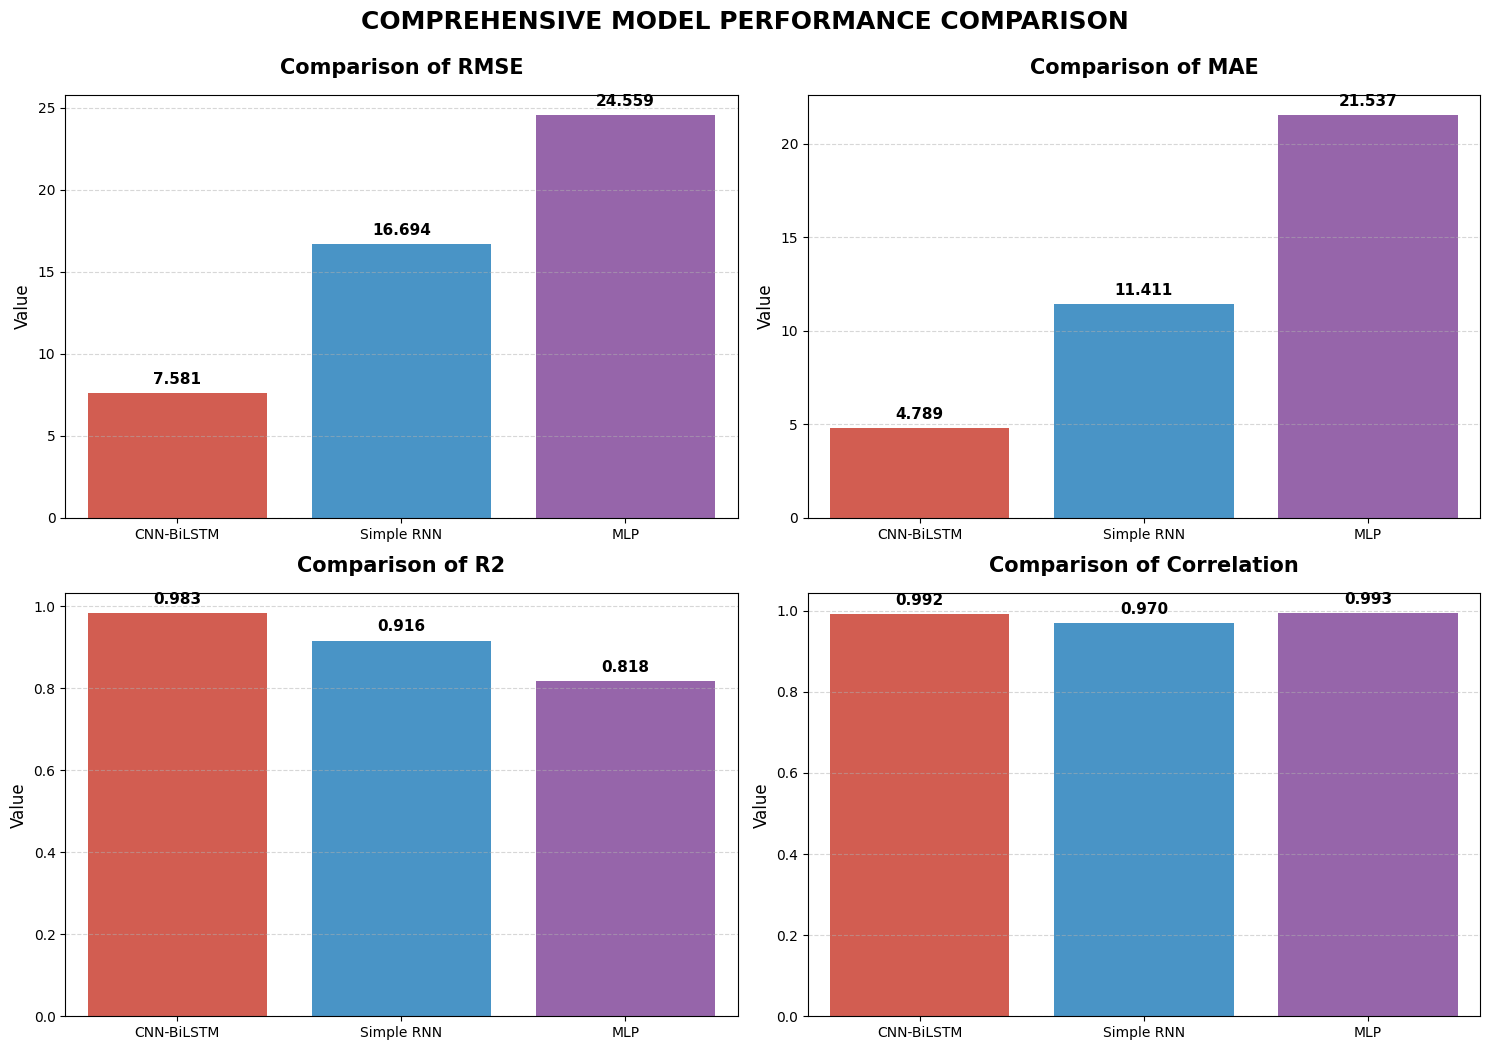

In [19]:
# --- BƯỚC 4: VẼ BIỂU ĐỒ BAR CHART ---
metrics_to_plot = ['RMSE', 'MAE', 'R2', 'Correlation']
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

# Màu sắc phân biệt
colors = ['#e74c3c', '#3498db', '#9b59b6'] # Đỏ, Xanh dương, Tím

for i, metric in enumerate(metrics_to_plot):
    # Lấy dữ liệu từ bảng đã xoay
    metric_values = final_comparison_table.loc[metric]
    
    sns.barplot(
        x=metric_values.index, 
        y=metric_values.values, 
        ax=axes[i], 
        palette=colors,
        hue=metric_values.index,
        legend=False
    )
    
    # Định dạng biểu đồ con
    axes[i].set_title(f'Comparison of {metric}', fontsize=15, fontweight='bold', pad=15)
    axes[i].set_ylabel('Value', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)
    
    # Ghi số liệu trên đầu cột
    for p in axes[i].patches:
        axes[i].annotate(format(p.get_height(), '.3f'), 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', 
                        xytext=(0, 10), 
                        textcoords='offset points',
                        fontweight='bold', fontsize=11)

# Tinh chỉnh tổng thể và lưu ảnh
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('COMPREHENSIVE MODEL PERFORMANCE COMPARISON', fontsize=18, fontweight='bold')
plt.savefig("comprehensive_comparison_charts.png", dpi=300, bbox_inches='tight')
plt.show()